# Function optimization

A common occurrence in several domains of engineering is that we need to optimize a certain function of some variables.  For example: $f(x) = x^2$.  Here we have a function of one variable ($x$) and we want to find the *minimum* value of that function over all values of $x$.  Of course, in this case we know that our objective is to minimize rather than maximize -- this may not always be the same option.

This of course is precisely what Calculus is so good at: by setting the derivative of the function to 0, we can solve the equation to find the value of $x$ that gives a possible optimum value.  In the present case, $f'(x) = 2x \Rightarrow x = 0$ will give us the *optimum* (in this case the minimum).

But what if we wanted to do this the *hard* way - actually do it numerically.  In this case it may be the painful way, but in general it might be useful.  So let us first get the big picture - what does our function actually look like?

In [1]:
# Set up the imports
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

-2.0 -1.9595959595959596


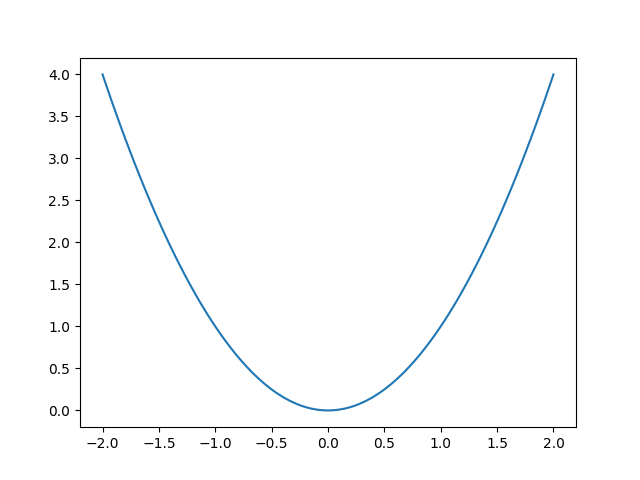

In [3]:

# Create the axis and function
xbase = np.linspace(-2, 2, 100)
def yfunc(x):
    return x ** 2
ybase = yfunc(xbase)
plt.plot(xbase, ybase)
print(xbase[0], xbase[1])

## Iterative improvement

If we don't know how to optimize, one possible approach is to throw darts - make a random guess, and see how good the present value is.  If the new value is better than the old one, retain it, else make a new guess.  Keep doing this for a large number of guesses.

Improved from 100000 at -100 to 2.1534527909837147 at -1.0739891950032434
Improved from 2.1534527909837147 at -1.0739891950032434 to 1.0024909668893072 at 0.04990958714823357
New cost 1.1016620057990734 worse than best so far: 1.0024909668893072
New cost 1.65963701343275 worse than best so far: 1.0024909668893072
New cost 1.4808902851079158 worse than best so far: 1.0024909668893072
New cost 1.2028844671638677 worse than best so far: 1.0024909668893072
New cost 2.953446759205505 worse than best so far: 1.0024909668893072
New cost 1.093920523000577 worse than best so far: 1.0024909668893072
New cost 2.945200880044049 worse than best so far: 1.0024909668893072
New cost 1.6729995225065988 worse than best so far: 1.0024909668893072
New cost 1.004498847062948 worse than best so far: 1.0024909668893072
New cost 2.784597395154031 worse than best so far: 1.0024909668893072
New cost 1.8505290986787097 worse than best so far: 1.0024909668893072
New cost 1.2692669932860303 worse than best so far:

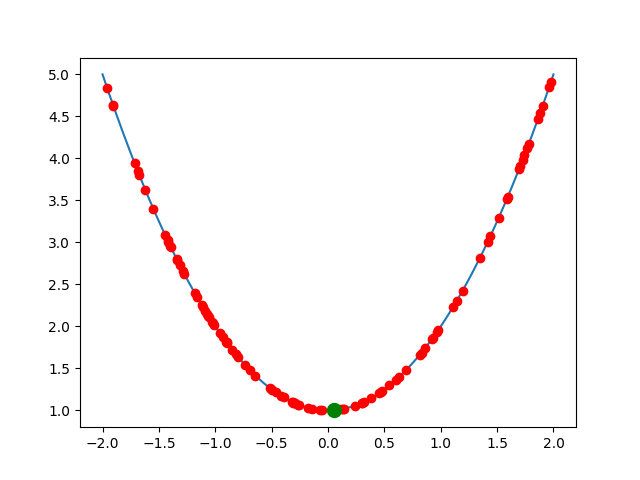

In [5]:
# Sample function to optimize (define this if not already defined)
def yfunc(x):
    return x**2 + 1  # Example function

xbase = np.linspace(-2, 2, 400)
ybase = yfunc(xbase)

bestcost = 100000
bestx = -100
rangemin, rangemax = -2, 2 

fig, ax = plt.subplots()
ax.plot(xbase, ybase)

xall, yall = [], []

lnall,  = ax.plot([], [], 'ro')                  # All points
lngood, = ax.plot([], [], 'go', markersize=10)   # Best point

def onestep(frame):
    global bestcost, bestx
    x = np.random.random_sample() * 4 - 2
    y = yfunc(x)

    if y < bestcost:
        print(f"Improved from {bestcost} at {bestx} to {y} at {x}")
        bestcost = y
        bestx = x
        lngood.set_data([x], [y])  # ✅ Fix here
    else:
        print(f"New cost {y} worse than best so far: {bestcost}")

    xall.append(x)
    yall.append(y)
    lnall.set_data(xall, yall)

    return lnall, lngood

from matplotlib.animation import FuncAnimation
ani = FuncAnimation(fig, onestep, frames=range(100), interval=1000, repeat=False)

from IPython.display import HTML
HTML(ani.to_jshtml())

plt.show()


## Systematic improvement

Instead of randomly guessing values, is there a better way to proceed?  What if we know what kind of change in $x$ would result in a good change in $y$?  Can we *guide* the optimization process so it reaches the minimum in fewer steps?

One way to do this is to recognize that at any point, the derivative of y can be used to guide the direction of improvement.  Let us say we are trying to minimize the function $f(x)$.

$$
f(x + dx) \approx f(x) + f'(x) dx
$$

If $f'(x)>0$, the curve is sloping upwards as we increase $x$.  So we should go in the opposite direction, that is, decrease $x$.  Alternatively, if $f'(x)<0$, the function will decrease if we increase $x$, so we should increase $x$.  In other words, either way we should go in the opposite direction to $f'(x)$.

### How much?

So we know the direction, but how much should we change $x$?  If we change by a constant amount, then the change in $f(x)$ will be proportional to the value of $f'$ at that point.  But intuitively, it would seem that if there is a rapid change in the function, then it makes sense to take a larger step in the hope of reaching the optimum faster.  

At the same time, too large a step could make us overshoot, and then we would have to come back.  

Finally, a fixed step size would eventually get us to the right place, but it could take a long time if we are far away from the optimum, even though the gradient indicates that there is likely to be a large change in the function.

This is captured using a parameter called the *learning rate*.  By modifying the learning rate, we can control how quickly we move towards the optimum.

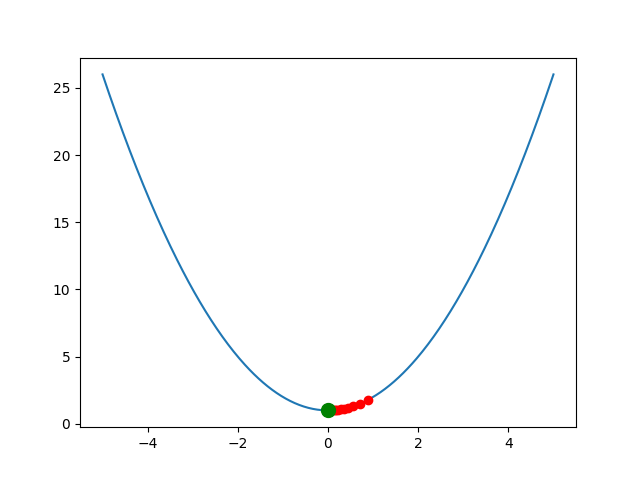

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Define the function and its derivative
def yfunc(x):
    return x**2 + 1

def yprimefunc(x):
    return 2 * x

# Create x values and y values for the curve
xbase = np.linspace(-5, 5, 400)
ybase = yfunc(xbase)

# Initial best cost and best x
bestcost = 100000
bestx = 1.1
rangemin, rangemax = -5, 5 

# Learning rate
lr = 0.1

# Set up the figure and plot
fig, ax = plt.subplots()
ax.plot(xbase, ybase)
xall, yall = [], []

lnall,  = ax.plot([], [], 'ro')
lngood, = ax.plot([], [], 'go', markersize=10)

def onestepderiv(frame):
    global bestcost, bestx, lr
    x = bestx - yprimefunc(bestx) * lr
    bestx = x
    y = yfunc(x)
    lngood.set_data([x], [y])  # ✅ Fixed here
    xall.append(x)
    yall.append(y)
    lnall.set_data(xall, yall)
    return lnall, lngood

ani = FuncAnimation(fig, onestepderiv, frames=range(100), interval=500, repeat=False)

# Display animation in Jupyter
HTML(ani.to_jshtml())


## Multiple optima

Consider the function $f(x) = x^4 - 2 x^3 + 3 x^2 + 5x +10$

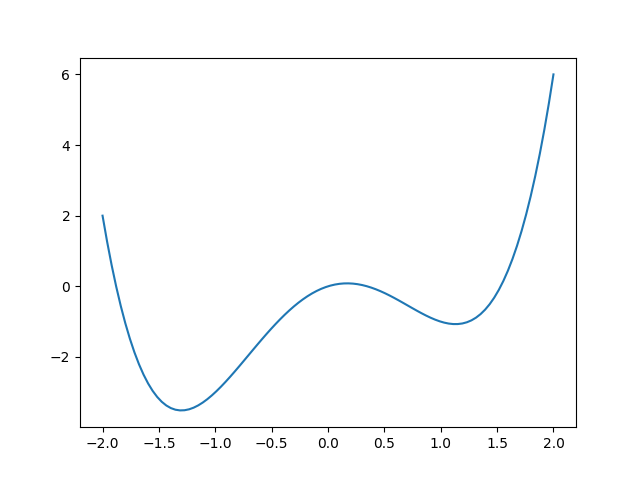

In [15]:
def cfunc(x):
    return x**4 - 3*x**2 + 1*x 

def cfuncd(x):
    return 4*x**3 -6*x + 1

xbase = np.linspace(-2, 2, 100)
ybase = cfunc(xbase)

plt.close()
plt.plot(xbase, ybase)
plt.show()

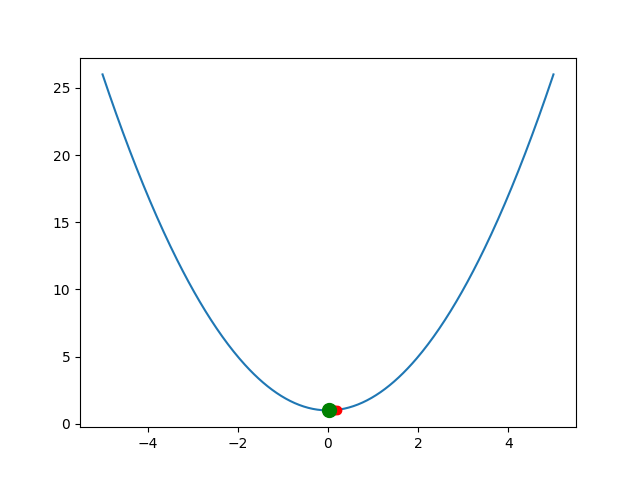

In [ ]:
# Set up some large value for the best cost found so far
bestcost = 100000
# Generate several values within a search 'space' and check whether the new value is better
# than the best seen so far.
bestx = 0.2
bestcost = cfunc(bestx)
rangemin, rangemax = -5, 5 
fig, ax = plt.subplots()
ax.plot(xbase, ybase)
xall, yall = [], []
lnall,  = ax.plot([], [], 'ro-')
lngood, = ax.plot([], [], 'go', markersize=10)

# Learning rate 
lr = 0.1

def onestepderiv(frame):
    global bestcost, bestx, lr
    lngood.set_data([bestx], [cfunc(bestx)])
    xall.append(bestx)
    yall.append(cfunc(bestx))
    x = bestx - cfuncd(bestx) * lr 
    bestx = x
    y = cfunc(x)
    lngood.set_data(x, y)
    lnall.set_data(xall, yall)
    return lngood,

ani1= FuncAnimation(fig, onestepderiv, frames=range(10), interval=1000, repeat=False)
plt.show()
from IPython.display import HTML
HTML(ani1.to_jshtml())